# EXPERIMENT NO. 3
# Part A — Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. DATA COLLECTION AND PREPARATION

In [2]:

df = pd.read_csv(r"C:\Users\hp\Downloads\USA_Housing.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

First 5 rows:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...

# 2. EDA


Statistical Summary:
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                       

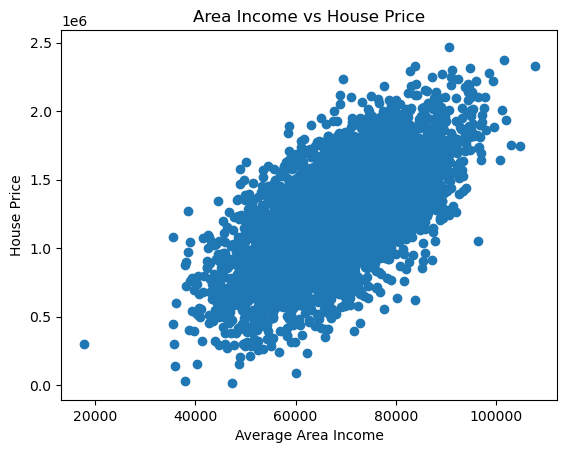

In [4]:
print("\nStatistical Summary:")
print(df.describe())

# Relationship between area income and price
plt.scatter(
    df["Avg. Area Income"],
    df["Price"]
)

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Area Income vs House Price")
plt.show()

# 3. DEFINE FEATURES AND TARGET

In [6]:
X = df[
    [
        "Avg. Area Income",
        "Avg. Area House Age",
        "Avg. Area Number of Rooms",
        "Avg. Area Number of Bedrooms",
        "Area Population"
    ]
]

y = df["Price"]


# 4. SPLIT DATASET

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", len(X_train))
print("Testing data:", len(X_test))


Training data: 4000
Testing data: 1000


# 5. MODEL TRAINING

In [8]:
model = LinearRegression()

# Ordinary Least Squares is used internally
model.fit(X_train, y_train)

print("\nModel trained successfully.")


Model trained successfully.


# 6. MODEL PARAMETERS

In [9]:
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(feature, ":", coefficient)


Intercept:
-2635072.9009313583

Coefficients:
Avg. Area Income : 21.65220576362364
Avg. Area House Age : 164666.4807218841
Avg. Area Number of Rooms : 119624.0122320596
Avg. Area Number of Bedrooms : 2440.377611027529
Area Population : 15.27031342991188


# 7. PREDICTION

y_pred = model.predict(X_test)

print("\nActual and Predicted Values:")

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result.head(10))

# 8. MODEL EVALUATION

In [11]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\n----- Evaluation -----")

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2 Score:", r2)


----- Evaluation -----
MSE : 10089009300.890957
RMSE: 100444.06055556973
MAE : 80879.09723487175
R2 Score: 0.9179971706834578


# 9. ACTUAL VS PREDICTED GRAPH

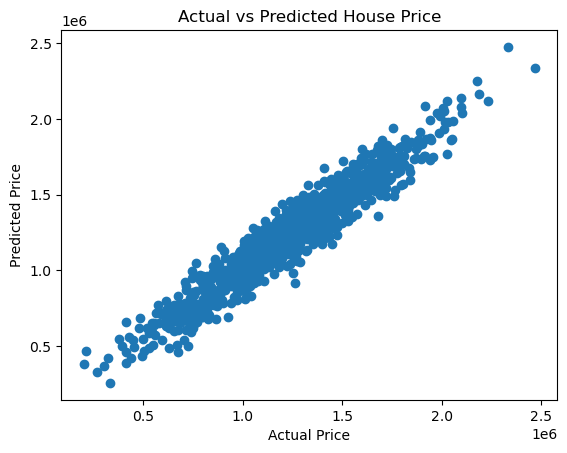

In [14]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()

# Part B — Logistic Regression

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# 1. DATA COLLECTION AND PREPARATION

In [16]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome

# 2. EDA


Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00

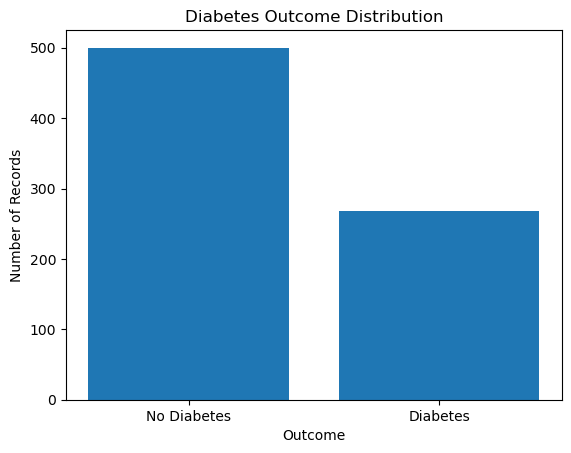

In [17]:
print("\nStatistical Summary:")
print(df.describe())

print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

# Outcome visualization
plt.bar(
    ["No Diabetes", "Diabetes"],
    df["Outcome"].value_counts().sort_index()
)

plt.xlabel("Outcome")
plt.ylabel("Number of Records")

plt.title("Diabetes Outcome Distribution")

plt.show()

# 3. DEFINE FEATURES AND TARGET

In [18]:
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

# 4. SPLIT DATASET

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", len(X_train))
print("Testing data:", len(X_test))


Training data: 614
Testing data: 154


# 5. FEATURE SCALING

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 6. MODEL TRAINING

In [21]:
model = LogisticRegression(
    max_iter=1000
)

# Maximum Likelihood Estimation is used
# for estimating the logistic regression parameters.

model.fit(
    X_train,
    y_train
)

print("\nModel trained successfully.")


Model trained successfully.


# 7. MODEL PARAMETERS

In [22]:
print("\nIntercept:")
print(model.intercept_[0])

print("\nCoefficients:")

for feature, coefficient in zip(
    df.drop("Outcome", axis=1).columns,
    model.coef_[0]
):
    print(feature, ":", coefficient)



Intercept:
-0.8749604861204671

Coefficients:
Pregnancies : 0.3731782104763501
Glucose : 1.1441512736875823
BloodPressure : -0.19763683090179182
SkinThickness : 0.06653497138971794
Insulin : -0.12730823048049894
BMI : 0.7138934066356619
DiabetesPedigreeFunction : 0.25552674669216924
Age : 0.18417898610631533


# 8. PREDICTION

In [23]:
y_pred = model.predict(X_test)

# Probability of class 1
probability = model.predict_proba(X_test)[:, 1]

print("\nPredicted probabilities:")
print(probability[:10])

print("\nPredicted classes:")
print(y_pred[:10])


Predicted probabilities:
[0.61667353 0.11278116 0.27253958 0.28668164 0.00448143 0.18904882
 0.46842913 0.91697653 0.10324589 0.78113127]

Predicted classes:
[1 0 0 0 0 0 0 1 0 1]


# 9. EVALUATION

In [24]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    probability
)

print("\n----- Evaluation -----")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)



----- Evaluation -----
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56
ROC-AUC  : 0.8229629629629629


# 10. CONFUSION MATRIX


Confusion Matrix:
[[82 18]
 [26 28]]


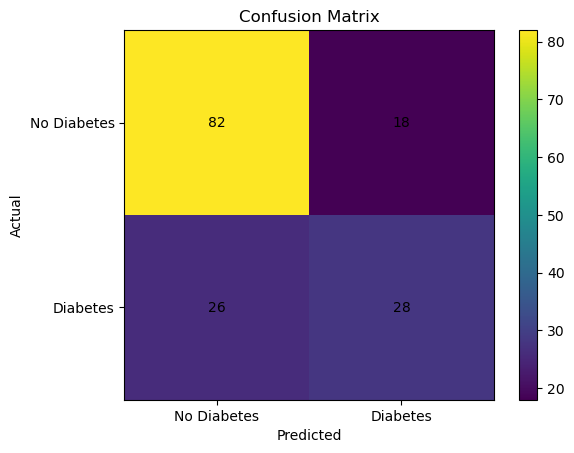

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()